In [33]:
# import torch
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt         # for the bottom diagram

class Perceptron:
    def __init__(self, weights, bias=1, learning_rate=0.3):
        """
        'weights' can be a numpy array, list or tuple with the actual values of the weights. The number of input values
        is indirectly defined by the length of 'weights'
        """
        self.weights = np.array(weights)
        self.bias = bias
        self.learning_rate = learning_rate

    @staticmethod
    def unit_step_function(x):
        if x <= 0:
            return 0
        else:
            return 1

    def __call__(self, in_data):
        in_data = np.concatenate((in_data, [self.bias]))    # concat the bias value - here it is 1
        # print('in_data', in_data)                         # now it is ex : [0 0 1]
        result = self.weights @ in_data                     # multiply matrix [ ] [ ]  - same size arrays
        # print('results', result)                            # exercise 1 example :  0.4384837125193516
        return Perceptron.unit_step_function(result)

    def adjust(self, target_result, in_data):
        if type(in_data) != np.ndarray:
            in_data = np.array(in_data)
        calculated_result = self(in_data)
        # print(calculated_result)
        error = target_result - calculated_result
        if error != 0:
            in_data = np.concatenate((in_data, [self.bias]))
            correction = error * in_data * self.learning_rate
            self.weights += correction

    def evaluate(self, data, labels):
        evaluation = Counter()
        for sample, label in zip(data, labels):
            result = self(sample)  # predict
            if result == label:
                evaluation["correct"] += 1
            else:
                evaluation["wrong"] += 1
        return evaluation

def labelled_samples(n):
    for _ in range(n):
        s = np.random.randint(0, 2, (2, ))              # if n=30, give 30 samples of [a b]  --> 0 and 1 combinations
        # print('s :', s)
        """
        s : [0 1]
        s : [0 1]
        s : [0 0]
        s : [0 1]
        s : [1 1]
        """
        yield (s, 1) if s[0] == 1 and s[1] == 1 else (s, 0)     # ex : return  [1 0] 0

Counter({'correct': 30})
-3.0000000000000004 3.0000000000000013


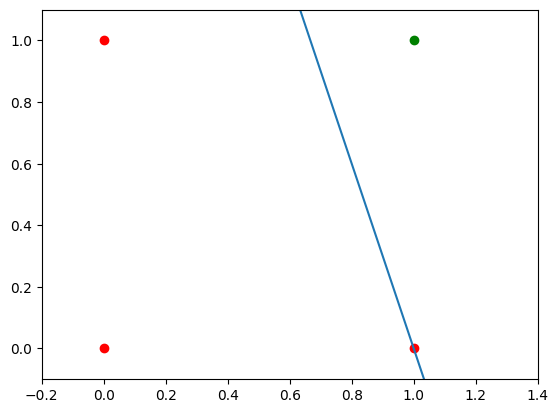

In [37]:
p = Perceptron(weights=[0.3, 0.3, 0.3], learning_rate=0.2)

# print('p', p)           # p <__main__.Perceptron object at 0x0000017CDD633A90>

for in_data, label in labelled_samples(30):                                         # ex:  [0 1] 0
    # print('in_data, label :', in_data, label)   # in_data, label : [1 1] 1
    p.adjust(label, in_data)

test_data, test_labels = list(zip(* labelled_samples(30)))

evaluation = p.evaluate(test_data, test_labels)
print(evaluation)

fig, ax = plt.subplots()
xmin, xmax = -0.2, 1.4
X = np.arange(xmin, xmax, 0.1)
# print(X)
ax.scatter(0, 0, color="r")
ax.scatter(0, 1, color="r")
ax.scatter(1, 0, color="r")
ax.scatter(1, 1, color="g")

ax.set_xlim([xmin, xmax])
ax.set_ylim([-0.1, 1.1])
m = -p.weights[0] / p.weights[1]
c = -p.weights[2] / p.weights[1]

print(m, c)
ax.plot(X, m * X + c)
plt.plot()
plt.show()